# Query Intent Evaluation

Run the rule-only query intent classifier evaluation.

In [2]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

## 1. Run Evaluation

In [ ]:
from src.evaluation.evaluate_query_intent import run_evaluation

outputs = run_evaluation(
    testset_path=repo_root / "data/eval/testset/classify_query_intent_v1.csv",
    dictionary_path=repo_root / "data/processed/kiwi_user_dict.tsv",
    output_dir=repo_root / "data/eval/outputs/query_intent",
)

print(f"full csv: {outputs.full_csv}")
print(f"errors csv: {outputs.errors_csv}")
print(f"summary json: {outputs.summary_json}")

## 2. Load Results

In [3]:
import json

import matplotlib.pyplot as plt
import pandas as pd

output_dir = repo_root / "data/eval/outputs/query_intent"

if "outputs" in globals():
    full_csv_path = Path(outputs.full_csv)
    errors_csv_path = Path(outputs.errors_csv)
    summary_json_path = Path(outputs.summary_json)
else:
    summary_json_path = max(output_dir.glob("query_intent_eval_v1_*_summary.json"), key=lambda p: p.stat().st_mtime)
    run_prefix = summary_json_path.name.removesuffix("_summary.json")
    full_csv_path = output_dir / f"{run_prefix}.csv"
    errors_csv_path = output_dir / f"{run_prefix}_errors.csv"

results_df = pd.read_csv(full_csv_path)
errors_df = pd.read_csv(errors_csv_path)
summary = json.loads(summary_json_path.read_text(encoding="utf-8"))

print(f"full csv: {full_csv_path}")
print(f"errors csv: {errors_csv_path}")
print(f"summary json: {summary_json_path}")
print(f"rows: {len(results_df):,}")

full csv: D:\AI\projects\finance-terms-rag-chatbot\data\eval\outputs\query_intent\query_intent_eval_v1_260606_2011.csv
errors csv: D:\AI\projects\finance-terms-rag-chatbot\data\eval\outputs\query_intent\query_intent_eval_v1_260606_2011_errors.csv
summary json: D:\AI\projects\finance-terms-rag-chatbot\data\eval\outputs\query_intent\query_intent_eval_v1_260606_2011_summary.json
rows: 30


## 3. Overall Summary

,metric,value
0,total_rows,30.000000
1,strict_intent_accuracy,0.766667
2,acceptable_intent_accuracy,0.766667
3,term_exact_match_rate,0.533333
4,average_term_precision,0.598333
5,average_term_recall,0.650000


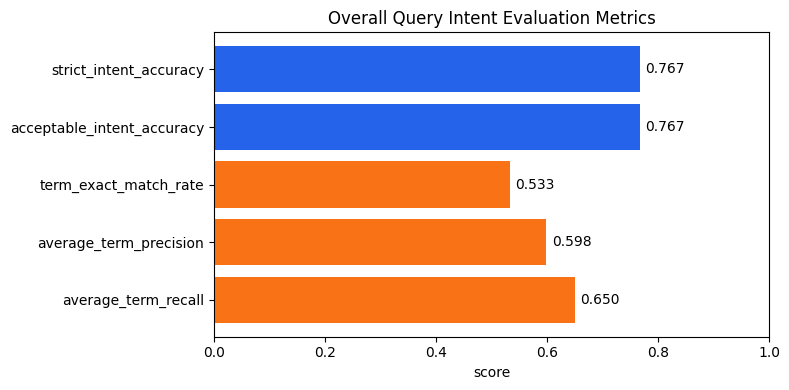

In [4]:
overall_metrics = pd.DataFrame(
    [
        {"metric": "total_rows", "value": summary["total_rows"]},
        {"metric": "strict_intent_accuracy", "value": summary["strict_intent_accuracy"]},
        {"metric": "acceptable_intent_accuracy", "value": summary["acceptable_intent_accuracy"]},
        {"metric": "term_exact_match_rate", "value": summary["term_exact_match_rate"]},
        {"metric": "average_term_precision", "value": summary["average_term_precision"]},
        {"metric": "average_term_recall", "value": summary["average_term_recall"]},
    ]
)

display(overall_metrics)

plot_metrics = overall_metrics[overall_metrics["metric"] != "total_rows"].copy()
plot_metrics = plot_metrics.iloc[::-1]
metric_colors = {
    "strict_intent_accuracy": "#2563eb",
    "acceptable_intent_accuracy": "#2563eb",
    "term_exact_match_rate": "#f97316",
    "average_term_precision": "#f97316",
    "average_term_recall": "#f97316",
}
colors = [metric_colors[metric] for metric in plot_metrics["metric"]]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(plot_metrics["metric"], plot_metrics["value"], color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel("score")
ax.set_title("Overall Query Intent Evaluation Metrics")
ax.bar_label(bars, fmt="%.3f", padding=4)
plt.tight_layout()

## 4. Category Summary

,category,count,strict_intent_accuracy,acceptable_intent_accuracy,term_exact_match_rate,average_term_precision,average_term_recall
0,ambiguous,3,0.333333,0.333333,0.333333,0.333333,0.333333
1,capability,4,0.750000,0.750000,0.750000,0.750000,0.750000
2,finance_concept,4,1.000000,1.000000,0.000000,0.187500,0.500000
3,greeting,4,0.750000,0.750000,1.000000,1.000000,1.000000
4,lexical_trap,7,0.714286,0.714286,0.428571,0.600000,0.642857
5,realtime_market,4,1.000000,1.000000,0.250000,0.250000,0.250000
6,unsupported_domain,4,0.750000,0.750000,1.000000,1.000000,1.000000


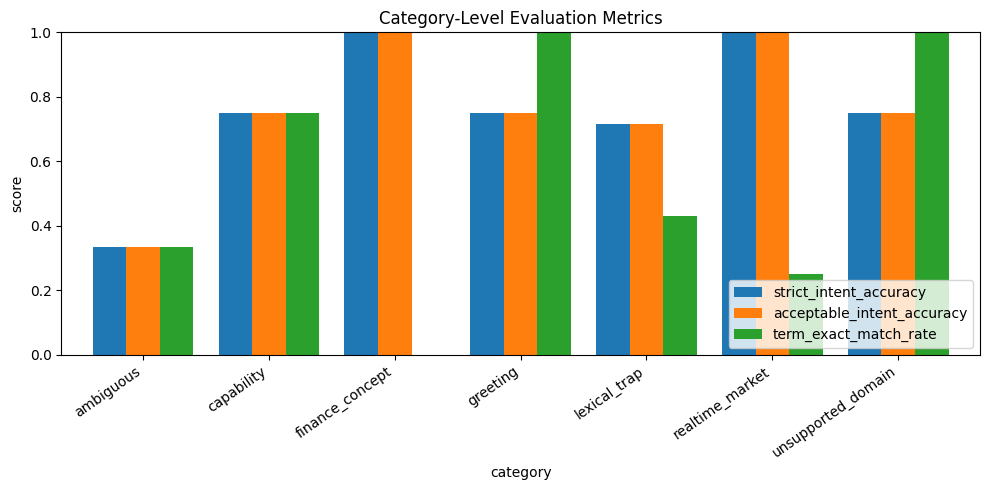

In [7]:
category_df = (
    pd.DataFrame.from_dict(summary["category_metrics"], orient="index")
    .rename_axis("category")
    .reset_index()
    .sort_values("category")
)

display(category_df)

category_plot = category_df.set_index("category")[[
    "strict_intent_accuracy",
    "acceptable_intent_accuracy",
    "term_exact_match_rate",
]]

fig, ax = plt.subplots(figsize=(10, 5))
category_plot.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylim(0, 1)
ax.set_xlabel("category")
ax.set_ylabel("score")
ax.set_title("Category-Level Evaluation Metrics")
ax.legend(loc="lower right")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

## 5. Confusion Matrix

predicted,clarify,needs_rag,needs_web,simple
expected,,,,
clarify,2,3,0,0
needs_rag,0,6,0,0
needs_web,0,0,4,0
simple,2,1,1,11


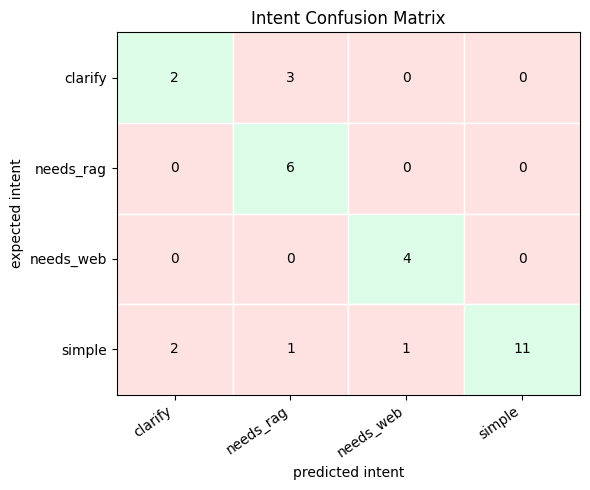

In [5]:
labels = sorted(set(results_df["expected_intent"]) | set(results_df["predicted_intent"]))
confusion_df = pd.crosstab(
    results_df["expected_intent"],
    results_df["predicted_intent"],
    rownames=["expected"],
    colnames=["predicted"],
    dropna=False,
).reindex(index=labels, columns=labels, fill_value=0)

display(confusion_df)

fig, ax = plt.subplots(figsize=(6, 5))
correct_color = "#dcfce7"
incorrect_color = "#fee2e2"

for row_idx in range(confusion_df.shape[0]):
    for col_idx in range(confusion_df.shape[1]):
        color = correct_color if row_idx == col_idx else incorrect_color
        rect = plt.Rectangle((col_idx - 0.5, row_idx - 0.5), 1, 1, facecolor=color, edgecolor="white")
        ax.add_patch(rect)

ax.set_xticks(range(len(labels)), labels=labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels=labels)
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(len(labels) - 0.5, -0.5)
ax.set_xlabel("predicted intent")
ax.set_ylabel("expected intent")
ax.set_title("Intent Confusion Matrix")

for row_idx in range(confusion_df.shape[0]):
    for col_idx in range(confusion_df.shape[1]):
        value = confusion_df.iat[row_idx, col_idx]
        ax.text(col_idx, row_idx, str(value), ha="center", va="center")

plt.tight_layout()

## 6. Error Review

In [9]:
error_columns = [
    "id",
    "category",
    "query",
    "expected_intent",
    "predicted_intent",
    "expected_matched_terms",
    "predicted_matched_terms",
    "strict_intent_ok",
    "acceptable_intent_ok",
    "term_exact_ok",
    "predicted_reason",
]

intent_errors = errors_df[
    (errors_df["strict_intent_ok"] == False)
    | (errors_df["acceptable_intent_ok"] == False)
].copy()

term_exact_errors = errors_df[
    errors_df["term_exact_ok"] == False
].copy()

print(f"total error rows: {len(errors_df):,}")
print(f"intent classification errors: {len(intent_errors):,}")
display(intent_errors[error_columns].sort_values(["category", "id"]))

print(f"term extraction errors: {len(term_exact_errors):,}")
display(term_exact_errors[error_columns].sort_values(["category", "id"]))

total error rows: 16
intent classification errors: 7


,id,category,query,expected_intent,predicted_intent,expected_matched_terms,predicted_matched_terms,strict_intent_ok,acceptable_intent_ok,term_exact_ok,predicted_reason
6,qi017,ambiguous,그거 차이가 뭐야?,clarify,needs_rag,[],"[""차이""]",False,False,False,matched_finance_terms
12,qi026,ambiguous,이 용어가 무슨 뜻이야?,clarify,needs_rag,[],"[""용어""]",False,False,False,matched_finance_terms
10,qi024,capability,이 챗봇은 금융 용어만 설명해?,simple,needs_rag,[],"[""금융"", ""용어"", ""설명""]",False,False,False,matched_finance_terms
5,qi009,greeting,하이 반가워,simple,clarify,[],[],False,False,True,rule_no_match
13,qi028,lexical_trap,공시라는 단어의 일반적인 뜻 알려줘,clarify,needs_rag,[],"[""공시"", ""일반""]",False,False,False,matched_finance_terms
14,qi029,lexical_trap,환율 효과라는 영화 있어?,simple,needs_web,[],"[""환율"", ""효과""]",False,False,False,matched_current_information_signal
11,qi025,unsupported_domain,파스타 레시피 알려줘,simple,clarify,[],[],False,False,True,rule_no_match


term extraction errors: 14


,id,category,query,expected_intent,predicted_intent,expected_matched_terms,predicted_matched_terms,strict_intent_ok,acceptable_intent_ok,term_exact_ok,predicted_reason
6,qi017,ambiguous,그거 차이가 뭐야?,clarify,needs_rag,[],"[""차이""]",False,False,False,matched_finance_terms
12,qi026,ambiguous,이 용어가 무슨 뜻이야?,clarify,needs_rag,[],"[""용어""]",False,False,False,matched_finance_terms
10,qi024,capability,이 챗봇은 금융 용어만 설명해?,simple,needs_rag,[],"[""금융"", ""용어"", ""설명""]",False,False,False,matched_finance_terms
0,qi001,finance_concept,가산금리란 무엇인가요?,needs_rag,needs_rag,"[""가산금리""]","[""가산금"", ""금리""]",True,True,False,matched_finance_terms
1,qi002,finance_concept,기준금리와 시장금리의 차이를 설명해줘,needs_rag,needs_rag,"[""기준금리"", ""시장금리""]","[""기준"", ""금리"", ""시장"", ""차이"", ""설명""]",True,True,False,matched_finance_terms
2,qi003,finance_concept,ETF의 장점과 위험은 뭐야?,needs_rag,needs_rag,"[""ETF""]","[""ETF"", ""위험""]",True,True,False,matched_finance_terms
8,qi021,finance_concept,예대율은 은행 건전성과 어떤 관련이 있어?,needs_rag,needs_rag,"[""예대율""]","[""예대율"", ""은행"", ""건전"", ""성과""]",True,True,False,matched_finance_terms
7,qi018,lexical_trap,금리와 주가의 관계는?,needs_rag,needs_rag,"[""금리"", ""주가""]","[""금리""]",True,True,False,matched_finance_terms
13,qi028,lexical_trap,공시라는 단어의 일반적인 뜻 알려줘,clarify,needs_rag,[],"[""공시"", ""일반""]",False,False,False,matched_finance_terms
14,qi029,lexical_trap,환율 효과라는 영화 있어?,simple,needs_web,[],"[""환율"", ""효과""]",False,False,False,matched_current_information_signal
